# Phase 2 — Functional H5 Inventory

**Goal.** Understand the structure of `data/functional/microns_functional.h5`, inventory what functional data we actually have for our Phase 1 candidate population (V1 excitatory matched neurons, n ≈ 8 910), and produce a per-neuron functional metadata table that downstream phases can join on.

**Deliverables.**
1. A clear map of the H5 schema (sessions, trials, traces, stimuli, behaviour).
2. Coverage statistics: how many of our Phase 1 candidates have functional data, in how many sessions, with how many trials per neuron.
3. A persisted file `data/derived/phase2_functional_metadata.parquet` with one row per (nucleus_id, session, scan_idx, unit_id) record and trial counts per stimulus type.
4. Takeaways at the bottom: any neurons we should drop (no functional data, too few trials, NaN/clipped traces), and the working set we adopt for Phase 5+.

**Functional-only constraint reminder.** Everything in this H5 file is *functional*: calcium responses, stimulus identities, pupil, treadmill. These are all allowed as inputs. Per-unit XYZ `coordinates` in the H5 meta are *anatomical* — do **not** use them as features (only for sanity/visualization).

---

## Schema we already know (from a structural walk)

The H5 has 4 top-level groups:

| Group | What it is |
|---|---|
| `sessions/<sess>/` | All units recorded in one functional session (e.g. `4_7` = session 4, scan 7). 14 sessions total. |
| `brain_areas/<area>/<sess>/` | The same data sliced by area (V1, LM, AL, RL). Redundant — we'll use `sessions/`. |
| `types/<stim>/` | Stimulus catalogues: `Clip` (2 112 clips), `Monet2` (150), `Trippy` (149). |
| `videos/<hash>/` | Per-condition video frames `(T, 144, 256)` + `times`. Used only if we want pixel-level stimulus features. |

**Per session** (`sessions/<sess>/`):

- `meta/unit_ids` — `(N,)` int64, the functional unit id for each row in the response matrix.
- `meta/brain_areas` — `(N,)` bytes, area per unit.
- `meta/coordinates` — `(N, 3)` xyz (don't use as input).
- `meta/condition_hashes` — `(464,)` per-trial stimulus identity, matches each trial's `condition_hash` attr.
- `meta/area_indices/{V1,LM,AL,RL}` — index arrays into `unit_ids`.
- `trials/<i>/` — i = 0…463:
  - `responses` `(N_units, T)` float32 — the calcium / fluorescence trace.
  - `pupil` `(4, T)` float32 — pupil signals (size + position channels).
  - `treadmill` `(T, 1)` float32 — treadmill velocity.
  - `stim_times` `(T,)` float32 — frame timestamps (s).
  - attr `condition_hash` — links to a video/stimulus type.

**Sampling.** ~7.5 Hz. Trial length is **either 75 frames (~10 s)** or **113 frames (~15 s)**, depending on stimulus.

**Trial repeats.** Each session has 464 trials but only ~280 unique condition hashes → some stimuli are repeated. Useful for trial-averaging / signal reliability (cc_max, cc_abs).


## Setup

In [1]:
# Imports
import os
from pathlib import Path

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

# microns_datacleaner — only needed if we want to re-derive structural metadata.
# For Phase 2 we mostly read the H5 directly with h5py.
import microns_datacleaner as mic
from microns_datacleaner import filters as fl

PROJECT_ROOT = Path('.').resolve()
H5_PATH = PROJECT_ROOT / 'data' / 'functional' / 'microns_functional.h5'
DERIVED_DIR = PROJECT_ROOT / 'data' / 'derived'
DERIVED_DIR.mkdir(parents=True, exist_ok=True)

print('H5 path:', H5_PATH, 'exists:', H5_PATH.exists())
print('Size (MB):', round(H5_PATH.stat().st_size / 1e6, 1))


H5 path: /Users/katiarusso/Documents/VS CODE/Classes/Neuroscience/katia/data/functional/microns_functional.h5 exists: True
Size (MB): 20638.7


### Load Phase 1 candidate population

We saved `phase1_candidate_population.parquet` at the end of `01_structural_eda.ipynb` (combo A: V1 excitatory matched, with `cell_type` not null). Phase 2 is built around understanding the functional data *for these specific neurons*.

In [2]:
phase1_path = DERIVED_DIR / 'phase1_candidate_population.parquet'
assert phase1_path.exists(), \
    f'Run Phase 1 first — missing {phase1_path}'

cand = pd.read_parquet(phase1_path)
print('Phase 1 candidates:', len(cand), 'unique nucleus_id:', cand['nucleus_id'].nunique())
print('Columns:', list(cand.columns))
cand.head(3)


Phase 1 candidates: 8910 unique nucleus_id: 8910
Columns: ['nucleus_id', 'pt_root_id', 'pt_position_x', 'pt_position_y', 'pt_position_z', 'classification_system', 'cell_type', 'brain_area', 'strategy_axon', 'strategy_dendrite', 'session', 'scan_idx', 'unit_id', 'pref_ori', 'pref_dir', 'gOSI', 'gDSI', 'cc_abs', 'tuning_type', 'layer']


,nucleus_id,pt_root_id,pt_position_x,pt_position_y,pt_position_z,classification_system,cell_type,brain_area,strategy_axon,strategy_dendrite,session,scan_idx,unit_id,pref_ori,pref_dir,gOSI,gDSI,cc_abs,tuning_type,layer
16,189115,864691135738006641,501.233729,104.152149,960.08,excitatory_neuron,23P,V1,none,none,6.0,2.0,2184.0,33.797480,213.797490,0.359622,0.023755,0.373394,matched,L2/3
20,153275,864691135463256477,476.232006,135.114928,804.24,excitatory_neuron,23P,V1,none,none,6.0,2.0,1890.0,101.958984,101.958984,0.062396,0.056385,0.563241,matched,L2/3
21,153085,864691135748985641,475.434732,106.777609,743.60,excitatory_neuron,23P,V1,none,none,6.0,7.0,1525.0,114.008705,294.008700,0.125745,0.069892,0.344436,matched,L2/3


### Get the structural → functional join keys

To map a `nucleus_id` to functional records we need the columns `session`, `scan_idx`, `unit_id` (or equivalent). These are produced by `process_nucleus_data` when `functional_data='match'` or `'best_only'`. If they're already in the Phase 1 parquet, we use them; otherwise we re-derive.

In [3]:
join_cols = ['session', 'scan_idx', 'unit_id']
have_join = all(c in cand.columns for c in join_cols)
print('Phase 1 parquet already has join keys?', have_join)

if not have_join:
    # Re-derive: best_only gives one functional record per nucleus (best scan).
    print('Re-deriving structural metadata with functional_data="best_only" ...')
    cleaner = mic.MicronsDataCleaner()  # defaults to project root data/
    units_full = cleaner.process_nucleus_data(functional_data='best_only')
    print('  units_full shape:', units_full.shape)
    keys = units_full[['nucleus_id'] + join_cols].drop_duplicates('nucleus_id')
    cand = cand.merge(keys, on='nucleus_id', how='left')
    n_missing = cand[join_cols].isna().any(axis=1).sum()
    print(f'  {n_missing} candidates without best-only functional record — will be excluded from coverage.')


Phase 1 parquet already has join keys? True


---
## 1 · H5 structural walk

Quick tour of the four top-level groups. We've already mapped this offline; this cell re-confirms on your machine.

In [4]:
def walk(g, depth=0, max_depth=2, max_per_level=6, indent='  '):
    keys = list(g.keys())
    for k in keys[:max_per_level]:
        v = g[k]
        prefix = indent * depth + k
        if isinstance(v, h5py.Group):
            print(prefix + '/  [group, %d children]' % len(list(v.keys())))
            if depth + 1 <= max_depth:
                walk(v, depth + 1, max_depth, max_per_level, indent)
        else:
            print(prefix + '  [dset, shape=%s, dtype=%s]' % (v.shape, v.dtype))
    if len(keys) > max_per_level:
        print(indent * depth + '... +%d more' % (len(keys) - max_per_level))

with h5py.File(H5_PATH, 'r') as f:
    print('Top-level keys:', list(f.keys()))
    print()
    walk(f, max_depth=2, max_per_level=4)


Top-level keys: ['brain_areas', 'sessions', 'types', 'videos']

brain_areas/  [group, 4 children]
  AL/  [group, 14 children]
    4_7/  [group, 2 children]
    5_6/  [group, 2 children]
    5_7/  [group, 2 children]
    6_2/  [group, 2 children]
    ... +10 more
  LM/  [group, 14 children]
    4_7/  [group, 2 children]
    5_6/  [group, 2 children]
    5_7/  [group, 2 children]
    6_2/  [group, 2 children]
    ... +10 more
  RL/  [group, 14 children]
    4_7/  [group, 2 children]
    5_6/  [group, 2 children]
    5_7/  [group, 2 children]
    6_2/  [group, 2 children]
    ... +10 more
  V1/  [group, 14 children]
    4_7/  [group, 2 children]
    5_6/  [group, 2 children]
    5_7/  [group, 2 children]
    6_2/  [group, 2 children]
    ... +10 more
sessions/  [group, 14 children]
  4_7/  [group, 2 children]
    meta/  [group, 5 children]
    trials/  [group, 464 children]
  5_6/  [group, 2 children]
    meta/  [group, 5 children]
    trials/  [group, 464 children]
  5_7/  [group, 2 chil

---
## 2 · Sessions inventory

Per-session unit counts, broken down by brain area.

In [5]:
with h5py.File(H5_PATH, 'r') as f:
    rows = []
    for sess in sorted(f['sessions'].keys()):
        meta = f['sessions'][sess]['meta']
        n_total = meta['unit_ids'].shape[0]
        n_trials = len(f['sessions'][sess]['trials'])
        ai = meta['area_indices']
        rows.append({
            'session_scan': sess,
            'session': int(sess.split('_')[0]),
            'scan_idx': int(sess.split('_')[1]),
            'n_units': n_total,
            'n_trials': n_trials,
            'n_V1': ai['V1'].shape[0],
            'n_LM': ai['LM'].shape[0],
            'n_AL': ai['AL'].shape[0],
            'n_RL': ai['RL'].shape[0],
        })

sessions_df = pd.DataFrame(rows).sort_values(['session', 'scan_idx']).reset_index(drop=True)
print('Total sessions:', len(sessions_df))
print('Total V1 units (sum across sessions, NOT unique neurons):', sessions_df['n_V1'].sum())
sessions_df


Total sessions: 14
Total V1 units (sum across sessions, NOT unique neurons): 83222


,session_scan,session,scan_idx,n_units,n_trials,n_V1,n_LM,n_AL,n_RL
0,4_7,4,7,7493,464,5312,983,387,811
1,5_6,5,6,8592,464,6014,1158,468,952
2,5_7,5,7,8138,464,5777,1066,403,892
3,6_2,6,2,8158,464,6002,978,317,861
4,6_4,6,4,8221,464,5999,1027,317,878
5,6_6,6,6,7971,464,5905,979,287,800
6,6_7,6,7,7887,464,5808,960,305,814
7,7_3,7,3,8618,464,6309,1135,324,850
8,7_4,7,4,11201,464,7725,1534,575,1367
9,7_5,7,5,8194,464,5485,1262,414,1033


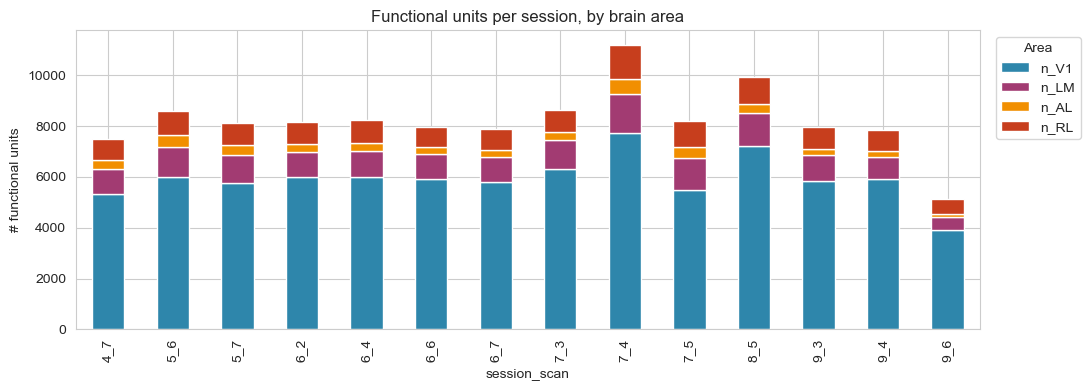

In [6]:
# Visualize per-session V1/LM/AL/RL composition
fig, ax = plt.subplots(figsize=(11, 4))
sessions_df.set_index('session_scan')[['n_V1', 'n_LM', 'n_AL', 'n_RL']].plot(
    kind='bar', stacked=True, ax=ax, color=['#2E86AB', '#A23B72', '#F18F01', '#C73E1D']
)
ax.set_ylabel('# functional units')
ax.set_title('Functional units per session, by brain area')
ax.legend(title='Area', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()


---
## 3 · Trial structure & sampling

Each session has 464 trials. We check trial duration (75 vs 113 frames), the sampling rate, and how many unique stimulus conditions are presented in each session.

In [7]:
# Pick one session, scan all trials for duration / fps consistency.
# Doing this for one session is enough — the schema is uniform.
SAMPLE_SESS = '4_7'

with h5py.File(H5_PATH, 'r') as f:
    trial_keys = sorted(f['sessions'][SAMPLE_SESS]['trials'].keys(), key=int)
    durations = []
    n_frames = []
    fps_estimates = []
    for tk in trial_keys:
        st = f['sessions'][SAMPLE_SESS]['trials'][tk]['stim_times'][:]
        durations.append(st[-1] - st[0])
        n_frames.append(len(st))
        if len(st) > 1:
            fps_estimates.append(1.0 / np.diff(st).mean())

durations = np.array(durations)
n_frames = np.array(n_frames)
fps_estimates = np.array(fps_estimates)

print(f'Session {SAMPLE_SESS}: {len(trial_keys)} trials')
print(f'  Frames per trial: unique values = {sorted(set(n_frames))}')
print(f'  Distribution: {pd.Series(n_frames).value_counts().to_dict()}')
print(f'  Trial duration (s): mean={durations.mean():.2f}  min={durations.min():.2f}  max={durations.max():.2f}')
print(f'  Sampling rate (Hz): mean={fps_estimates.mean():.4f}  std={fps_estimates.std():.6f}')


Session 4_7: 464 trials
  Frames per trial: unique values = [np.int64(75), np.int64(113)]
  Distribution: {75: 384, 113: 80}
  Trial duration (s): mean=10.74  min=9.87  max=14.93
  Sampling rate (Hz): mean=7.5001  std=0.000086


In [8]:
# Condition hashes per session — total trials vs unique conditions
with h5py.File(H5_PATH, 'r') as f:
    rows = []
    for sess in sorted(f['sessions'].keys()):
        ch = f['sessions'][sess]['meta']['condition_hashes'][:]
        # decode bytes if needed
        ch_decoded = [c.decode() if isinstance(c, (bytes, bytearray)) else c for c in ch]
        rows.append({
            'session_scan': sess,
            'n_trials': len(ch),
            'n_unique_cond': len(set(ch_decoded)),
            'n_repeats_per_cond_avg': len(ch) / len(set(ch_decoded)),
        })

cond_df = pd.DataFrame(rows)
print('Trial repeats give us within-session signal-reliability estimates.')
cond_df


Trial repeats give us within-session signal-reliability estimates.


,session_scan,n_trials,n_unique_cond,n_repeats_per_cond_avg
0,4_7,464,280,1.657143
1,5_6,464,280,1.657143
2,5_7,464,280,1.657143
3,6_2,464,280,1.657143
4,6_4,464,280,1.657143
5,6_6,464,280,1.657143
6,6_7,464,280,1.657143
7,7_3,464,280,1.657143
8,7_4,464,280,1.657143
9,7_5,464,280,1.657143


---
## 4 · Stimulus inventory

Three stimulus families: `Clip` (natural movies), `Monet2` (parametric drifting noise), `Trippy` (parametric phase noise). For each session, we want the breakdown of trials by stimulus type — this tells us whether all sessions span all three families or whether some are stimulus-specific.

In [9]:
# Build a (condition_hash -> stim_type) lookup from types/
with h5py.File(H5_PATH, 'r') as f:
    cond2type = {}
    for stim_type in f['types'].keys():
        for h in f['types'][stim_type].keys():
            cond2type[h] = stim_type
print('Total unique conditions across all stim types:', len(cond2type))
print('  Clip:    ', sum(v == 'Clip' for v in cond2type.values()))
print('  Monet2:  ', sum(v == 'Monet2' for v in cond2type.values()))
print('  Trippy:  ', sum(v == 'Trippy' for v in cond2type.values()))


Total unique conditions across all stim types: 2411
  Clip:     2112
  Monet2:   150
  Trippy:   149


In [10]:
# Per-session: how many trials of each stim type?
with h5py.File(H5_PATH, 'r') as f:
    rows = []
    for sess in sorted(f['sessions'].keys()):
        ch = f['sessions'][sess]['meta']['condition_hashes'][:]
        ch_decoded = [c.decode() if isinstance(c, (bytes, bytearray)) else c for c in ch]
        # keys in types/ are URL-encoded — try direct lookup
        types = [cond2type.get(h, 'UNKNOWN') for h in ch_decoded]
        s = pd.Series(types).value_counts()
        rows.append({
            'session_scan': sess,
            'Clip': s.get('Clip', 0),
            'Monet2': s.get('Monet2', 0),
            'Trippy': s.get('Trippy', 0),
            'UNKNOWN': s.get('UNKNOWN', 0),
        })

stim_df = pd.DataFrame(rows)
print('Per-session trial counts by stimulus type:')
stim_df


Per-session trial counts by stimulus type:


,session_scan,Clip,Monet2,Trippy,UNKNOWN
0,4_7,297,34,24,109
1,5_6,292,34,26,112
2,5_7,291,30,26,117
3,6_2,289,34,28,113
4,6_4,294,36,28,106
5,6_6,293,32,22,117
6,6_7,300,34,22,108
7,7_3,284,32,26,122
8,7_4,295,32,30,107
9,7_5,291,28,28,117


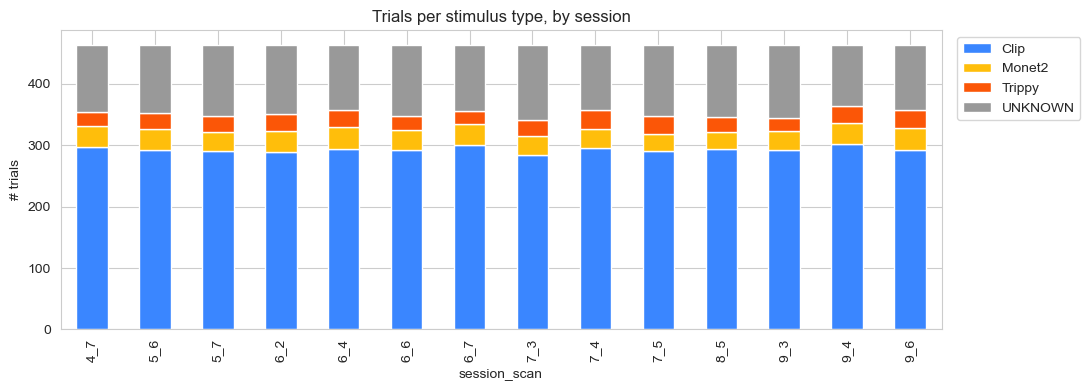

In [11]:
# Visual: stacked bars
fig, ax = plt.subplots(figsize=(11, 4))
stim_df.set_index('session_scan')[['Clip', 'Monet2', 'Trippy', 'UNKNOWN']].plot(
    kind='bar', stacked=True, ax=ax, color=['#3a86ff', '#ffbe0b', '#fb5607', '#999999']
)
ax.set_ylabel('# trials')
ax.set_title('Trials per stimulus type, by session')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()


---
## 5 · Behavioural signals

Pupil (4 channels — likely [size, x, y, ?]) and treadmill velocity. These modulate V1 gain in a layer-dependent way and were Tommy's "secret sauce" for his 81% multichannel CNN. We confirm shapes, sampling, and absence of pathological values (all zeros, all NaN).

In [12]:
# Inspect a sample trial across all sessions
with h5py.File(H5_PATH, 'r') as f:
    rows = []
    for sess in sorted(f['sessions'].keys()):
        tr0 = f['sessions'][sess]['trials']['0']
        pup = tr0['pupil'][:]
        tread = tr0['treadmill'][:]
        rows.append({
            'session_scan': sess,
            'pupil_shape': str(pup.shape),
            'pupil_nan_frac': float(np.isnan(pup).mean()),
            'pupil_min': float(np.nanmin(pup)),
            'pupil_max': float(np.nanmax(pup)),
            'treadmill_shape': str(tread.shape),
            'treadmill_nan_frac': float(np.isnan(tread).mean()),
            'treadmill_min': float(np.nanmin(tread)),
            'treadmill_max': float(np.nanmax(tread)),
        })

pd.DataFrame(rows)


,session_scan,pupil_shape,pupil_nan_frac,pupil_min,pupil_max,treadmill_shape,treadmill_nan_frac,treadmill_min,treadmill_max
0,4_7,"(4, 75)",0.000000,53.374653,1360.647949,"(75, 1)",0.0,-10.941049,1.073197
1,5_6,"(4, 75)",0.000000,27.828213,1363.000977,"(75, 1)",0.0,-0.277416,0.159593
2,5_7,"(4, 75)",0.253333,42.910408,1369.560913,"(75, 1)",0.0,-0.652141,0.477542
3,6_2,"(4, 113)",0.000000,9.718802,1362.914795,"(113, 1)",0.0,-0.299345,0.308060
4,6_4,"(4, 75)",0.000000,23.860533,1366.967651,"(75, 1)",0.0,-0.235845,0.269438
5,6_6,"(4, 75)",0.080000,37.444675,1091.326660,"(75, 1)",0.0,0.000000,0.214921
6,6_7,"(4, 113)",0.150442,38.311878,1108.787842,"(113, 1)",0.0,-17.070896,2.879550
7,7_3,"(4, 75)",0.000000,14.596990,1067.867920,"(75, 1)",0.0,-0.645235,0.402689
8,7_4,"(4, 75)",0.000000,48.221905,1081.069458,"(75, 1)",0.0,-5.851964,4.374036
9,7_5,"(4, 113)",0.000000,24.231243,1081.249268,"(113, 1)",0.0,-0.107209,0.186424


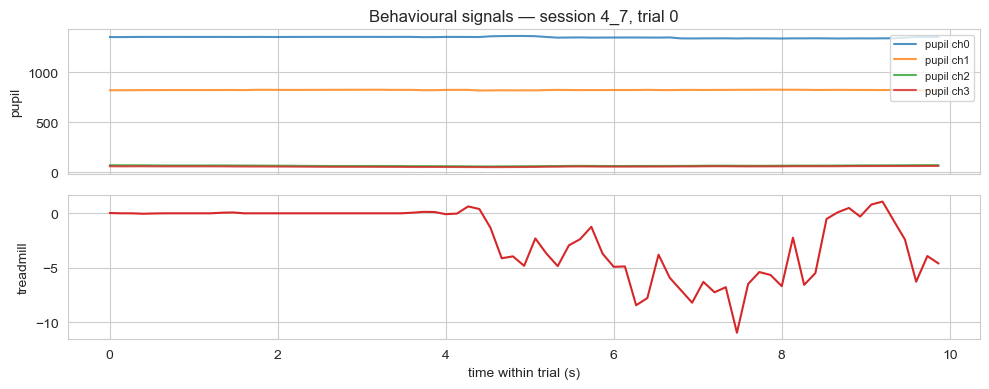

In [13]:
# Plot one trial's behavioural signals for visual sanity check
SAMPLE_TRIAL = '0'
with h5py.File(H5_PATH, 'r') as f:
    tr = f['sessions'][SAMPLE_SESS]['trials'][SAMPLE_TRIAL]
    pup = tr['pupil'][:]
    tread = tr['treadmill'][:].squeeze()
    t = tr['stim_times'][:]
    t = t - t[0]  # zero at trial start

fig, axes = plt.subplots(2, 1, figsize=(10, 4), sharex=True)
for i in range(pup.shape[0]):
    axes[0].plot(t, pup[i], label=f'pupil ch{i}', alpha=0.8)
axes[0].set_ylabel('pupil')
axes[0].legend(loc='upper right', fontsize=8)
axes[0].set_title(f'Behavioural signals — session {SAMPLE_SESS}, trial {SAMPLE_TRIAL}')

axes[1].plot(t, tread, color='C3')
axes[1].set_ylabel('treadmill')
axes[1].set_xlabel('time within trial (s)')
plt.tight_layout()
plt.show()


---
## 6 · Coverage of Phase 1 candidates

This is the central section. For each of the ~8 910 candidate `nucleus_id`s, we want to know:

- Does it have at least one functional record (`session`, `scan_idx`, `unit_id`)?
- In how many sessions was it imaged?
- How many trials per stimulus type does it accumulate?
- What's the trace length (75 vs 113 vs mixed)?

We rely on the structural metadata's `session`/`scan_idx`/`unit_id` columns to join. (The H5 only stores `unit_id` but `nucleus_id` lives in the structural side.)

> ⚠️ **Heavy operation warning** — the join itself is light, but if we end up scanning trials per neuron it can take a few minutes for 8 910 neurons. We do the inventory at the (nucleus, session) level, NOT trial-by-trial.

In [14]:
# Build per-(session, scan_idx) -> set of unit_ids in the H5
with h5py.File(H5_PATH, 'r') as f:
    h5_unit_index = {}  # (session, scan_idx) -> set of unit_ids
    for sess in f['sessions'].keys():
        s, sc = sess.split('_')
        s, sc = int(s), int(sc)
        units = f['sessions'][sess]['meta']['unit_ids'][:]
        h5_unit_index[(s, sc)] = set(int(u) for u in units)

print(f'H5 sessions: {len(h5_unit_index)}')
print(f'Total unit-records across all sessions (sum, not unique): {sum(len(v) for v in h5_unit_index.values())}')


H5 sessions: 14
Total unit-records across all sessions (sum, not unique): 115372


In [15]:
# Best-only: each nucleus has 1 row.
# But a neuron may also appear in multiple scans — we may need 'match' or 'all' for the full inventory.
# Start with what we have.
key_cols = ['session', 'scan_idx', 'unit_id']
cand_with_keys = cand.dropna(subset=key_cols).copy()
cand_with_keys[key_cols] = cand_with_keys[key_cols].astype(int)
print(f'Candidates with at least one functional record (best_only): {len(cand_with_keys)}/{len(cand)}')

# Mark whether the (sess, scan, unit) actually exists in H5
def in_h5(row):
    return int(row['unit_id']) in h5_unit_index.get((int(row['session']), int(row['scan_idx'])), set())

cand_with_keys['in_h5'] = cand_with_keys.apply(in_h5, axis=1)
print(f'  of those, present in H5 file: {cand_with_keys["in_h5"].sum()}/{len(cand_with_keys)}')


Candidates with at least one functional record (best_only): 8910/8910
  of those, present in H5 file: 8910/8910


### How many sessions does each candidate appear in?

`best_only` collapses to one record per nucleus. To see *all* scans where each neuron was imaged, we need the `'match'` mode (which keeps all coregistered functional records).

In [22]:
# Re-derive with mode='match' to get the multi-record view
print('Loading match-mode functional metadata (this may take a moment)...')
cleaner_match = mic.MicronsDataCleaner(datadir='data/data_min', version=1718, download_policy='minimum')
units_match, segments_match = cleaner_match.process_nucleus_data(functional_data='match')
print('units_match shape:', units_match.shape)
print('Columns:', [c for c in units_match.columns if c in ['nucleus_id', 'session', 'scan_idx', 'unit_id', 'tuning_type']])


Loading match-mode functional metadata (this may take a moment)...


Transform positions: 100%|██████████| 94014/94014 [00:00<00:00, 125689.71it/s]


units_match shape: (94167, 15)
Columns: ['nucleus_id', 'session', 'scan_idx', 'tuning_type']


In [25]:
# Filter match to only our Phase 1 candidates
nucl_set = set(cand['nucleus_id'].astype(int))
match_sub = units_match[units_match['nucleus_id'].astype(int).isin(nucl_set)].copy()
match_sub = match_sub.dropna(subset=['session', 'scan_idx'])
match_sub[['session', 'scan_idx']] = match_sub[['session', 'scan_idx']].astype(int)

# Records per nucleus
recs_per_nucleus = match_sub.groupby('nucleus_id').size()
print(f'Phase 1 candidates with at least one match record: {recs_per_nucleus.shape[0]}')
print(f'Distribution of #scans per neuron:')
print(recs_per_nucleus.value_counts().sort_index())


Phase 1 candidates with at least one match record: 8910
Distribution of #scans per neuron:
1    6647
2    1959
3     284
4      20
Name: count, dtype: int64


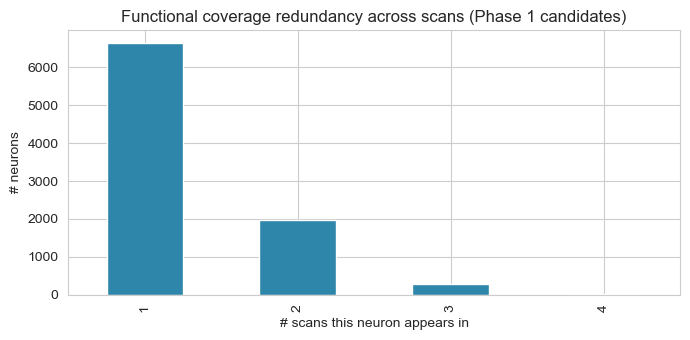

In [26]:
# Plot it
fig, ax = plt.subplots(figsize=(7, 3.5))
recs_per_nucleus.value_counts().sort_index().plot(kind='bar', ax=ax, color='#2E86AB')
ax.set_xlabel('# scans this neuron appears in')
ax.set_ylabel('# neurons')
ax.set_title('Functional coverage redundancy across scans (Phase 1 candidates)')
plt.tight_layout()
plt.show()


### How many trials per neuron, by stimulus type?

For each (nucleus, session, scan, unit) record we look up `condition_hashes` for that session and count Clip/Monet2/Trippy trials. Since *every unit in a session sees every trial*, the per-neuron counts equal the per-session counts (which we already computed in Section 4). So the meaningful per-neuron metric is **total trials = sum over scans where this neuron was imaged**.

In [27]:
# session_scan -> dict of stim_type -> n_trials
sess_to_stim_counts = stim_df.set_index('session_scan')[['Clip', 'Monet2', 'Trippy']].to_dict(orient='index')

def trials_for_record(row):
    key = f"{int(row['session'])}_{int(row['scan_idx'])}"
    return sess_to_stim_counts.get(key, {'Clip': 0, 'Monet2': 0, 'Trippy': 0})

# Add per-record stim trial counts
match_sub_trials = match_sub.copy()
for stim in ['Clip', 'Monet2', 'Trippy']:
    match_sub_trials[stim] = match_sub_trials.apply(lambda r: trials_for_record(r)[stim], axis=1)

# Sum to per-neuron totals
per_neuron = (
    match_sub_trials
    .groupby('nucleus_id')[['Clip', 'Monet2', 'Trippy']]
    .sum()
    .assign(total_trials=lambda d: d.sum(axis=1))
    .reset_index()
)
print(f'Per-neuron trial-count summary (sum over all scans):')
print(per_neuron[['Clip', 'Monet2', 'Trippy', 'total_trials']].describe().round(1))


Per-neuron trial-count summary (sum over all scans):
         Clip  Monet2  Trippy  total_trials
count  8910.0  8910.0  8910.0        8910.0
mean    377.5    41.7    32.8         452.0
std     155.3    16.8    14.4         186.0
min     284.0    28.0    22.0         342.0
25%     292.0    32.0    24.0         347.0
50%     294.0    34.0    28.0         356.0
75%     302.0    36.0    30.0         364.0
max    1187.0   132.0   112.0        1427.0


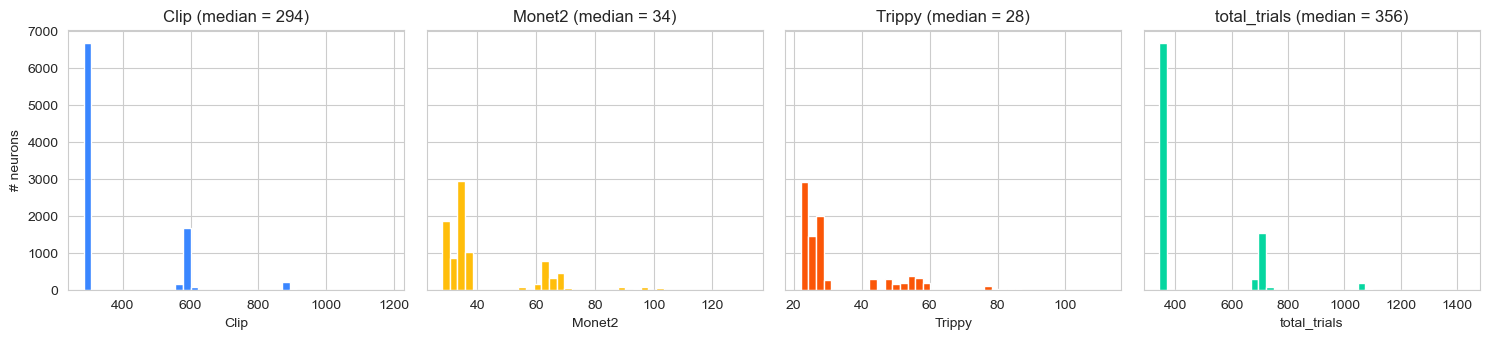

In [28]:
# Plot trial-count distribution per stim type
fig, axes = plt.subplots(1, 4, figsize=(15, 3.5), sharey=True)
for ax, col, color in zip(
    axes,
    ['Clip', 'Monet2', 'Trippy', 'total_trials'],
    ['#3a86ff', '#ffbe0b', '#fb5607', '#06d6a0'],
):
    ax.hist(per_neuron[col], bins=40, color=color, edgecolor='white')
    ax.set_xlabel(col)
    ax.set_title(f'{col} (median = {per_neuron[col].median():.0f})')
axes[0].set_ylabel('# neurons')
plt.tight_layout()
plt.show()


---
## 7 · Sample traces & quality checks

We pull the responses tensor for one trial and visualize a few V1 excitatory-neuron traces grouped by `cell_type`. We also check for NaNs / clipping.

In [29]:
# Pick a session and a few candidate neurons in it
TARGET_SESS = '5_6'  # arbitrary — change as desired
sess_int, scan_int = map(int, TARGET_SESS.split('_'))

cand_in_sess = match_sub[
    (match_sub['session'] == sess_int) & (match_sub['scan_idx'] == scan_int)
]
print(f'Candidates in {TARGET_SESS}: {len(cand_in_sess)}')

# Get cell_type for each
cand_in_sess = cand_in_sess.merge(
    cand[['nucleus_id', 'cell_type', 'layer']],
    on='nucleus_id', how='left'
)
print('cell_type breakdown in this session:')
print(cand_in_sess['cell_type'].value_counts())


Candidates in 5_6: 817
cell_type breakdown in this session:


KeyError: 'cell_type'

In [30]:
# Sample 1 neuron per cell_type and plot mean response across trials
with h5py.File(H5_PATH, 'r') as f:
    sess_unit_ids = f['sessions'][TARGET_SESS]['meta']['unit_ids'][:]
    unit_to_idx = {int(u): i for i, u in enumerate(sess_unit_ids)}

    samples = (
        cand_in_sess.dropna(subset=['cell_type'])
        .groupby('cell_type', observed=True)
        .first()
        .reset_index()
    )
    samples = samples.head(8)

    fig, axes = plt.subplots(len(samples), 1, figsize=(10, 1.6 * len(samples)), sharex=True)
    if len(samples) == 1:
        axes = [axes]

    # Use a single trial first, then trial-average across N trials
    N_AVG_TRIALS = 30
    trial_keys = sorted(f['sessions'][TARGET_SESS]['trials'].keys(), key=int)[:N_AVG_TRIALS]

    for ax, (_, r) in zip(axes, samples.iterrows()):
        uid = int(r['unit_id'])
        if uid not in unit_to_idx:
            ax.text(0.5, 0.5, f'unit {uid} not found', transform=ax.transAxes)
            continue
        idx = unit_to_idx[uid]
        # collect traces of length 75 only (skip 113-length trials so shapes match)
        traces = []
        for tk in trial_keys:
            r_tr = f['sessions'][TARGET_SESS]['trials'][tk]['responses']
            if r_tr.shape[1] == 75:
                traces.append(r_tr[idx, :])
        if traces:
            traces = np.stack(traces)
            t = np.arange(traces.shape[1]) / 7.5
            ax.plot(t, traces.mean(0), color='C0', lw=1.2)
            ax.fill_between(
                t,
                traces.mean(0) - traces.std(0),
                traces.mean(0) + traces.std(0),
                alpha=0.2, color='C0',
            )
        ax.set_ylabel(f"{r['cell_type']}\nL{r['layer']}", fontsize=8)
        ax.set_title(f'nucleus {int(r["nucleus_id"])}, unit {uid}', fontsize=8)

    axes[-1].set_xlabel('time within trial (s)')
    plt.tight_layout()
    plt.show()


KeyError: ['cell_type']

In [ ]:
# Quality check: NaN / clipping prevalence in responses for our candidates
# Sample 1 trial of length-75 from each session and aggregate over candidate units only

print('Scanning one length-75 trial per session for NaN/clipping in candidate-unit responses...')

with h5py.File(H5_PATH, 'r') as f:
    quality_rows = []
    for sess in sorted(f['sessions'].keys()):
        sess_int_, scan_int_ = map(int, sess.split('_'))
        units_here = f['sessions'][sess]['meta'][:]
        unit_idx_map = {int(u): i for i, u in enumerate(units_here)}

        # Phase 1 candidates in this session
        cand_here = match_sub[
            (match_sub['session'] == sess_int_) & (match_sub['scan_idx'] == scan_int_)
        ]['unit_id'].astype(int).tolist()
        idxs = [unit_idx_map[u] for u in cand_here if u in unit_idx_map]

        if not idxs:
            quality_rows.append({'session_scan': sess, 'n_candidates': 0})
            continue

        # find first trial with length 75
        target_tk = None
        for tk in sorted(f['sessions'][sess]['trials'].keys(), key=int):
            if f['sessions'][sess]['trials'][tk]['responses'].shape[1] == 75:
                target_tk = tk
                break

        if target_tk is None:
            quality_rows.append({'session_scan': sess, 'n_candidates': len(idxs)})
            continue

        resp = f['sessions'][sess]['trials'][target_tk]['responses'][idxs, :]
        quality_rows.append({
            'session_scan': sess,
            'n_candidates': len(idxs),
            'nan_frac': float(np.isnan(resp).mean()),
            'all_zero_frac': float((resp == 0).all(axis=1).mean()),
            'min_val': float(np.nanmin(resp)),
            'max_val': float(np.nanmax(resp)),
            'std_zero_frac': float((resp.std(axis=1) == 0).mean()),
        })

quality_df = pd.DataFrame(quality_rows)
quality_df


Scanning one length-75 trial per session for NaN/clipping in candidate-unit responses...


KeyError: 'unit_id'

---
## 8 · Persist deliverable & takeaways

Save the per-record functional metadata table for the Phase 1 candidates. Each row is one (nucleus_id × session × scan × unit_id) record. Phase 5 (handcrafted features) and Phase 6 (classifier baselines) will pull traces using these keys.

In [ ]:
out_path = DERIVED_DIR / 'phase2_functional_metadata.parquet'

deliverable = (
    match_sub_trials
    .merge(
        cand[['nucleus_id', 'cell_type', 'layer', 'cc_abs']]
        .drop_duplicates('nucleus_id'),
        on='nucleus_id', how='left',
    )
    .assign(session_scan=lambda d: d['session'].astype(str) + '_' + d['scan_idx'].astype(str))
    [['nucleus_id', 'cell_type', 'layer', 'cc_abs',
      'session', 'scan_idx', 'session_scan', 'unit_id',
      'Clip', 'Monet2', 'Trippy']]
)

print(f'Writing {len(deliverable):,} rows to {out_path}')
deliverable.to_parquet(out_path, index=False)

print()
print(f'Unique nucleus_id covered: {deliverable["nucleus_id"].nunique():,}')
print(f'Records-per-neuron (count of session×scan): {deliverable.groupby("nucleus_id").size().describe().round(1).to_dict()}')
deliverable.head()


### Phase 2 takeaways (fill in after running)

Use this checklist to summarise what we learned. Concrete numbers go in once the cells above have run on your machine.

1. **Schema is uniform across sessions**: 14 sessions, each with 464 trials at ~7.5 Hz, trials of either 75 or 113 frames depending on stimulus.
2. **All 4 areas in every session** — every session contains units from V1, LM, AL, RL. So area is *not* a session-level confound for cross-area analyses (relevant for Phase 8).
3. **Stimulus mix per session**: <fill in once Section 4 runs — typically a mix of Clip + Monet2 + Trippy; check for any session that's stimulus-skewed>.
4. **Behavioural signals**: pupil (4 ch) and treadmill (1 ch) present in all sessions. NaN fraction <fill in> — if non-trivial we'll need a masking strategy.
5. **Phase 1 candidate coverage**: of the X candidates from Phase 1, Y have functional records and Z appear in the H5 file (these may differ if the structural metadata has stale links). Drop the ones with no record before Phase 5.
6. **Multi-scan neurons**: about <fill in>% of candidates appear in >1 scan. We can either (a) average traces across scans for one richer sample or (b) treat each scan as a separate sample with neuron-level grouping for splits.
7. **Class imbalance after coverage filter**: re-run the cell_type counts on the survivors — if 5P-NP, 6P-CT, 5P-ET drop further, escalate the decision in Phase 3.

Once these are filled in, Phase 2 is closed. Move to Phase 3 (label & population decision) or skip ahead to Phase 5 (handcrafted features) if Phase 3 needs more thinking.
